# Monte Carlo Option Pricing Engine

This project uses Monte Carlo simulation to estimate the value of a European call option under geometric Brownian motion.

The simulated price is compared with the analytical Black–Scholes price. The project then investigates how the number of simulations affects pricing accuracy, estimation error and computation time.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.stats import norm


In [41]:
# Option and market parameters
S0 = 100       # Current stock price
K = 100        # Strike price
T = 1.0        # Time until expiry in years
r = 0.05       # Annual risk-free interest rate
sigma = 0.20   # Annual volatility

# Simulation settings
n_simulations = 100_000
random_seed = 42

np.random.seed(random_seed)

In [42]:
print(f"Current stock price: £{S0}")
print(f"Strike price: £{K}")
print(f"Time to expiry: {T} year")
print(f"Risk-free rate: {r:.1%}")
print(f"Volatility: {sigma:.1%}")
print(f"Number of simulations: {n_simulations:,}")

Current stock price: £100
Strike price: £100
Time to expiry: 1.0 year
Risk-free rate: 5.0%
Volatility: 20.0%
Number of simulations: 100,000


## Monte Carlo Simulation

We simulate possible stock prices at expiry using geometric Brownian motion under the risk-neutral measure.

In [43]:
# Generate 100,000 random shocks from a standard normal distribution
Z = np.random.standard_normal(n_simulations)

# Simulate the stock price at expiry
ST = S0 * np.exp(
    (r - 0.5 * sigma**2) * T
    + sigma * np.sqrt(T) * Z
)

print("First 10 simulated stock prices:")
print(ST[:10])

print(f"\nAverage simulated final price: £{np.mean(ST):.2f}")
print(f"Lowest simulated final price: £{np.min(ST):.2f}")
print(f"Highest simulated final price: £{np.max(ST):.2f}")

First 10 simulated stock prices:
[113.8080226  100.23498965 117.29684912 139.73896651  98.33101696
  98.33133983 141.31801116 120.1399282   93.81036104 114.85634743]

Average simulated final price: £105.15
Lowest simulated final price: £42.18
Highest simulated final price: £252.39


## European Call Option Pricing

The payoff of a European call option at expiry is:

\[
\max(S_T-K,0)
\]

We calculate this payoff for every simulation, take the average and discount it back to its present value.

In [44]:
# Calculate the call payoff in every simulated scenario
call_payoffs = np.maximum(ST - K, 0)

# Average the future payoffs
average_payoff = np.mean(call_payoffs)

# Discount the average payoff back to today's value
discount_factor = np.exp(-r * T)
monte_carlo_price = discount_factor * average_payoff

print(f"Average payoff at expiry: £{average_payoff:.4f}")
print(f"Discount factor: {discount_factor:.4f}")
print(f"Monte Carlo call price: £{monte_carlo_price:.4f}")

Average payoff at expiry: £11.0109
Discount factor: 0.9512
Monte Carlo call price: £10.4739


## Black–Scholes Benchmark

The analytical Black–Scholes formula provides a benchmark for assessing the accuracy of the Monte Carlo estimate.

In [45]:
def black_scholes_call(S0, K, T, r, sigma):
    d1 = (
        np.log(S0 / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    call_price = (
        S0 * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

    return call_price


black_scholes_price = black_scholes_call(S0, K, T, r, sigma)

absolute_error = abs(monte_carlo_price - black_scholes_price)
percentage_error = absolute_error / black_scholes_price * 100

print(f"Monte Carlo price: £{monte_carlo_price:.4f}")
print(f"Black–Scholes price: £{black_scholes_price:.4f}")
print(f"Absolute pricing error: £{absolute_error:.4f}")
print(f"Percentage error: {percentage_error:.4f}%")

Monte Carlo price: £10.4739
Black–Scholes price: £10.4506
Absolute pricing error: £0.0233
Percentage error: 0.2230%


## Distribution of Simulated Stock Prices

The histogram below shows the distribution of simulated stock prices at expiry. The strike price separates scenarios where the call option expires worthless from those where it finishes in the money.

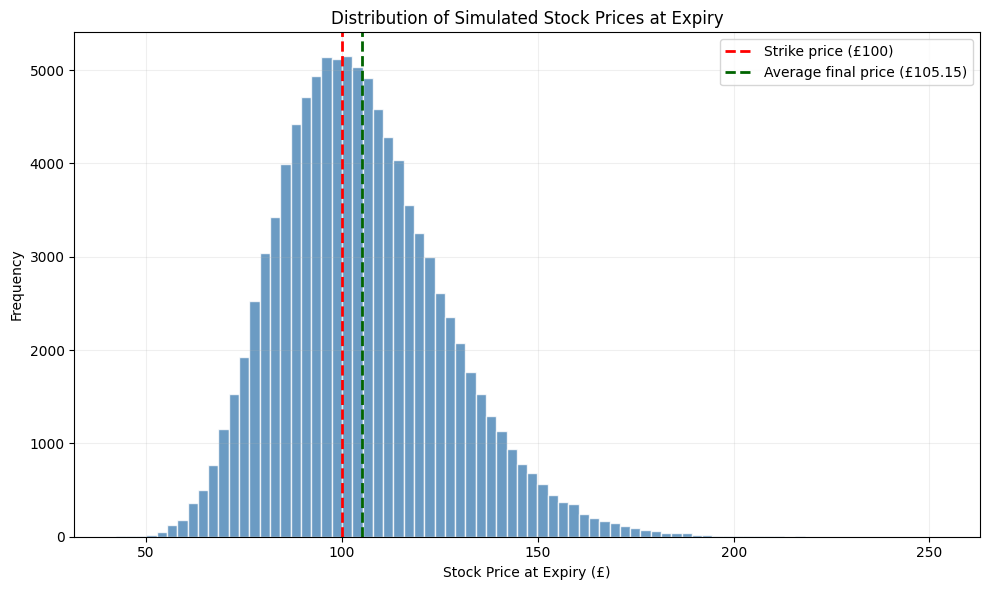

In [46]:
plt.figure(figsize=(10, 6))

plt.hist(
    ST,
    bins=80,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

plt.axvline(
    K,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Strike price (£{K})"
)

plt.axvline(
    np.mean(ST),
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label=f"Average final price (£{np.mean(ST):.2f})"
)

plt.title("Distribution of Simulated Stock Prices at Expiry")
plt.xlabel("Stock Price at Expiry (£)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()

plt.savefig(
    "simulated_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Convergence and Computational Cost

Monte Carlo estimates contain sampling error. This experiment tests how the estimated option price, pricing error and computation time change as the number of simulations increases.

In [47]:
simulation_sizes = [
    100,
    500,
    1_000,
    5_000,
    10_000,
    50_000,
    100_000,
    500_000,
    1_000_000
]

results = []

for n in simulation_sizes:
    # Resetting the seed makes the experiment reproducible
    np.random.seed(random_seed)

    start_time = time.perf_counter()

    # Simulate final stock prices
    Z = np.random.standard_normal(n)

    simulated_prices = S0 * np.exp(
        (r - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * Z
    )

    # Calculate and discount the call payoffs
    payoffs = np.maximum(simulated_prices - K, 0)
    estimated_price = np.exp(-r * T) * np.mean(payoffs)

    end_time = time.perf_counter()

    # Measure accuracy and speed
    pricing_error = abs(estimated_price - black_scholes_price)
    computation_time = end_time - start_time

    results.append({
        "Simulations": n,
        "Monte Carlo Price": estimated_price,
        "Absolute Error": pricing_error,
        "Computation Time (seconds)": computation_time
    })

results_df = pd.DataFrame(results)

results_df

,Simulations,Monte Carlo Price,Absolute Error,Computation Time (seconds)
0,100,8.159991,2.290592,0.000205
1,500,10.377643,0.072941,0.000077
2,1000,10.516569,0.065986,0.000230
3,5000,10.485018,0.034434,0.000304
4,10000,10.450170,0.000414,0.000590
5,50000,10.446164,0.004419,0.002468
6,100000,10.473892,0.023308,0.002949
7,500000,10.441324,0.009260,0.015278
8,1000000,10.434158,0.016426,0.031288


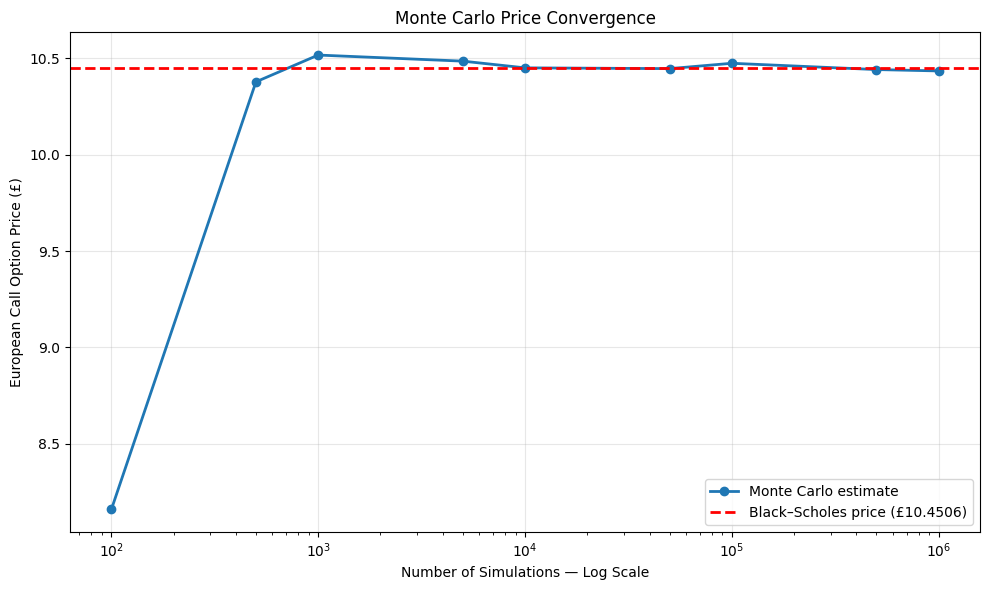

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(
    results_df["Simulations"],
    results_df["Monte Carlo Price"],
    marker="o",
    linewidth=2,
    label="Monte Carlo estimate"
)

plt.axhline(
    black_scholes_price,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Black–Scholes price (£{black_scholes_price:.4f})"
)

plt.xscale("log")
plt.title("Monte Carlo Price Convergence")
plt.xlabel("Number of Simulations — Log Scale")
plt.ylabel("European Call Option Price (£)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "monte_carlo_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Confidence Interval

Because Monte Carlo pricing uses random samples, the estimate contains statistical uncertainty. A 95% confidence interval provides a range of plausible values for the true option price.

In [49]:
# Standard error of the discounted Monte Carlo payoff
standard_error = (
    discount_factor
    * np.std(call_payoffs, ddof=1)
    / np.sqrt(n_simulations)
)

# Construct a 95% confidence interval
confidence_level = 1.96

lower_bound = monte_carlo_price - confidence_level * standard_error
upper_bound = monte_carlo_price + confidence_level * standard_error

print(f"Monte Carlo estimate: £{monte_carlo_price:.4f}")
print(f"Standard error: £{standard_error:.4f}")
print(f"95% confidence interval: [£{lower_bound:.4f}, £{upper_bound:.4f}]")
print(f"Black–Scholes price: £{black_scholes_price:.4f}")

if lower_bound <= black_scholes_price <= upper_bound:
    print("The Black–Scholes price lies inside the confidence interval.")
else:
    print("The Black–Scholes price lies outside the confidence interval.")

Monte Carlo estimate: £10.4739
Standard error: £0.0466
95% confidence interval: [£10.3826, £10.5652]
Black–Scholes price: £10.4506
The Black–Scholes price lies inside the confidence interval.


## Results and Interpretation

Using 100,000 simulations, the Monte Carlo model estimated the European call option price at **£10.4739**. The analytical Black–Scholes price was **£10.4506**, producing an absolute error of approximately **£0.0233**, or **0.223%**.

The Black–Scholes value also fell within the Monte Carlo model's 95% confidence interval. This indicates that the difference between the two estimates was consistent with ordinary sampling uncertainty.

The convergence experiment showed that estimates based on small sample sizes fluctuated considerably. As the number of simulations increased, the estimates became more stable and generally moved closer to the Black–Scholes benchmark. However, convergence was not perfectly smooth because every Monte Carlo estimate remained subject to random sampling error.

The experiment demonstrates the trade-off between statistical precision and computational cost: larger simulations generally improve reliability but require more processing time.

## Model Limitations

The model relies on several restrictive assumptions:

- Volatility remains constant throughout the option's life.
- The risk-free interest rate is constant.
- Stock prices follow geometric Brownian motion.
- Returns are lognormally distributed without sudden price jumps.
- Markets are perfectly liquid.
- Trading occurs continuously.
- There are no transaction costs or taxes.
- The option can only be exercised at expiry.

Real markets can experience changing volatility, extreme returns, liquidity constraints and sudden price jumps. The model also does not reproduce features such as the volatility smile. Therefore, it provides a useful theoretical benchmark rather than a complete representation of real financial markets.

## Conclusion

This project successfully implemented a Monte Carlo engine for pricing a European call option. Possible terminal stock prices were simulated under risk-neutral geometric Brownian motion, and the discounted average payoff was used to estimate the option's present value.

The estimate was validated against the analytical Black–Scholes price and was found to be highly accurate. A convergence experiment and confidence interval were used to evaluate sampling uncertainty and demonstrate how simulation size affects reliability.

The project developed practical experience in Python, NumPy, probability, financial modelling, data visualisation and model validation. A possible extension would be to price put options, calculate option Greeks, introduce variance-reduction techniques or apply the model to more complicated path-dependent derivatives.